# Exploración geoespacial — Nuevo Liberalismo y Carlos Fernando Galán

Este cuaderno junta dos miradas que suelen contarse por separado: el partido a escala nacional y el histórico electoral de Carlos Fernando Galán a escala distrital (Bogotá); este último también incluye sus participaciones como candidato en el partido Cambio Radical.

## Bibliotecas y bases de datos

In [1]:
import os
os.environ["SHAPE_ENCODING"] = "UTF-8"
import unicodedata, re
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROC = ROOT / "data" / "processed"
GEO = ROOT / "data" / "raw" / "geodata"

def norm_key(x):
    if pd.isna(x): return np.nan
    x = str(x).strip().lower()
    x = unicodedata.normalize("NFKD", x).encode("ascii","ignore").decode("utf-8")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    return re.sub(r"\s+", " ", x).strip()

plt.rcParams["figure.figsize"] = [12, 7]
print("ROOT:", ROOT)

nl = pd.read_parquet(PROC / "nuevo_liberalismo.parquet")
gal = pd.read_parquet(PROC / "carlos_fernando_galan.parquet")
print(f"Partido: {nl.shape[0]:,} filas, {nl['ano'].min()}–{nl['ano'].max()}, {nl['partido'].nunique()} etiquetas de coalición")
print(f"Galán:   {gal.shape[0]:,} filas, años {sorted(gal['ano'].unique().tolist())}")
print(f"Galán — estado geográfico: {gal['geo_flag'].value_counts().to_dict()}")


ROOT: c:\Users\qluis\Documents\Proyectos\Analítica electoral
Partido: 1,092,477 filas, 1982–2026, 21 etiquetas de coalición
Galán:   3,179 filas, años [2007, 2011, 2014, 2019, 2023]
Galán — estado geográfico: {'ok': 2990, 'inconsistente_loc_upz': 105, 'upz_nula': 74, 'nacional_sin_codigo': 10}


## 1. ¿Qué traen los dos datasets?

In [3]:

print(f"Cobertura cod_dpto_geo (partido): {nl['cod_dpto_geo'].notna().mean():.1%} — sin código: {nl['cod_dpto_geo'].isna().sum():,}")
print(nl[nl["cod_dpto_geo"].isna()].groupby("departamento").size().to_string())

print(f"\nCobertura localidad (Galán, sin NACIONAL): {gal[gal['localidad']!='nacional']['cod_localidad'].notna().mean():.1%}")
print(gal["geo_flag"].value_counts().to_string())

print("\nVolumen por año y corporación (partido):")
print(nl.groupby(["ano","corporacion"]).size().to_string())


Cobertura cod_dpto_geo (partido): 99.2% — sin código: 8,648
departamento
consulados    8646
sin_dato         2

Cobertura localidad (Galán, sin NACIONAL): 100.0%
geo_flag
ok                       2990
inconsistente_loc_upz     105
upz_nula                   74
nacional_sin_codigo        10

Volumen por año y corporación (partido):
ano   corporacion           
1982  camara                       110
      presidencia                 1059
      senado                       286
1986  asamblea departamental      4149
      camara                      3155
      concejo                     1000
      senado                      2308
1988  alcaldia                       8
      asamblea departamental      2180
2022  camara                    113773
      senado                     74641
2023  alcaldia                   30340
      asamblea departamental     83256
      concejo                   405621
      gobernacion                12726
      jal                       163686
2026  camara  

## 2. El partido visto desde el territorio

Si hay una idea que salta a la vista es la hiperconcentración en Bogotá. La capital reúne sola más votos que varios departamentos juntos, y eso no es solo por población: refleja donde el Nuevo Liberalismo ha logrado sostener estructura. El Gini de 0.72 formaliza esa intuición —una distribución muy desigual, casi de tipo capital-primado—. Para la estrategia, esto pesa: lo que pase en Bogotá arrastra el total nacional, mientras que departamentos como Guainía o Vaupés, aunque numerosos en municipios, pesan poco en votos.

                   votos  registros  municipios
departamento                                   
bogota           3703294     430545           1
cundinamarca      476058      58134         117
santander         403691      68697          88
antioquia         353655      37357         133
valle del cauca   336612      32216          42
atlantico         276658      64182          23
cordoba           221954      29445          31
boyaca            207323      43756         143
tolima            206970      33830          48
huila             180985      13508          37

Gini entre departamentos: 0.716 — alta concentración


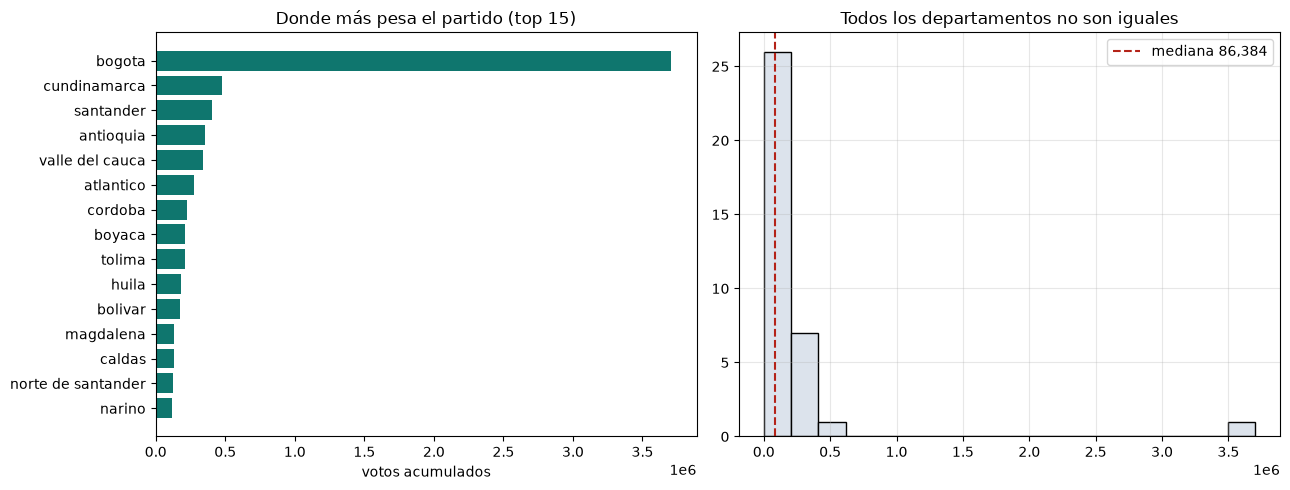

In [4]:

dept = nl.groupby("departamento").agg(votos=("votos","sum"), registros=("votos","size"), municipios=("municipio","nunique")).sort_values("votos", ascending=False)
print(dept.head(10).to_string())

# Gini breve
vs = dept["votos"].sort_values()
gini = (2*np.arange(1, len(vs)+1)-len(vs)-1).dot(np.sort(vs.values)) / (len(vs)*vs.sum())
print(f"\nGini entre departamentos: {gini:.3f} — alta concentración")

# Gráficos simples
fig, axes = plt.subplots(1,2, figsize=(13,5))
tmp = dept.head(15).sort_values("votos")
axes[0].barh(tmp.index.astype(str), tmp["votos"], color="#0F766E")
axes[0].set_title("Donde más pesa el partido (top 15)")
axes[0].set_xlabel("votos acumulados")

vs.hist(bins=18, ax=axes[1], color="#DCE3EC", edgecolor="black")
axes[1].axvline(vs.median(), color="#B42318", ls="--", label=f"mediana {vs.median():,.0f}")
axes[1].set_title("Todos los departamentos no son iguales"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Galán en Bogotá: localidades y UPZ

Aquí la historia se vuelve más barrial. Suba y Kennedy, por volumen, encabezan la lista —son localidades grandes y populosas, era esperable—, pero cuando miramos por UPZ aparecen matices: Bosa Central o Tibabuyes concentran tanto que una sola UPZ equivale a varias localidades pequeñas. Esto sugiere dos escalas de trabajo distintas: una estrategia de *cobertura* por localidad y otra de *intensidad* por UPZ, donde cada puesto cuenta mucho.

Es clave analizar los resultados en términos del teorema del límite central. Que Suba y Kennedy, así como Bosa Cental y Tibabúyes (upz) sean territorios con gran capital electoral es clave, en términos de la cantidad de sus habitantes. 

In [5]:

upz_stats = gal.groupby("upz").agg(votos=("votacion","sum"), puestos=("votacion","count"), promedio=("votacion","mean")).sort_values("votos", ascending=False)
print(f"{len(upz_stats)} UPZ con datos — {upz_stats['votos'].sum():,.0f} votos en total")
print(upz_stats.head(10).to_string())

loc_stats = gal.groupby("localidad").agg(votos=("votacion","sum"), puestos=("votacion","count")).sort_values("votos", ascending=False)
print("\nPor localidad:")
print(loc_stats.to_string())


107 UPZ con datos — 2,893,409 votos en total
                 votos  puestos     promedio
upz                                         
bosa central     80538      103   781.922330
tibabuyes        71496       54  1324.000000
los cedros       69289       32  2165.281250
fontibon         69247       59  1173.677966
el rincon        67634       44  1537.136364
boyaca real      64821       65   997.246154
kennedy central  60125       70   858.928571
quinta paredes   55399       20  2769.950000
santa barbara    53987       17  3175.705882
garces navas     53687       42  1278.261905

Por localidad:
                     votos  puestos
localidad                          
suba                445640      299
kennedy             335830      367
engativa            318990      310
usaquen             288316      168
bosa                181947      216
ciudad bolivar      174172      244
fontibon            161184      139
san cristobal       122115      180
puente aranda       120547      169
raf

## 4. ¿Cómo se distribuye el voto en el mapa?

El coroplético confirma lo que dicen las tablas pero con geografía: el occidente y el norte de Bogotá —Suba, Engativá, Kennedy— aparecen más intensos, mientras que el centro histórico y Sumapaz quedan tenues. La curva de Lorenz, con Gini 0.38, cuenta otra parte: dentro de Bogotá el voto de Galán está bastante más repartido que el del partido a nivel nacional. No hay una UPZ que monopolice; es una base relativamente distribuida, lo que habla de un respaldo transversal en la ciudad más que de un bastión único.

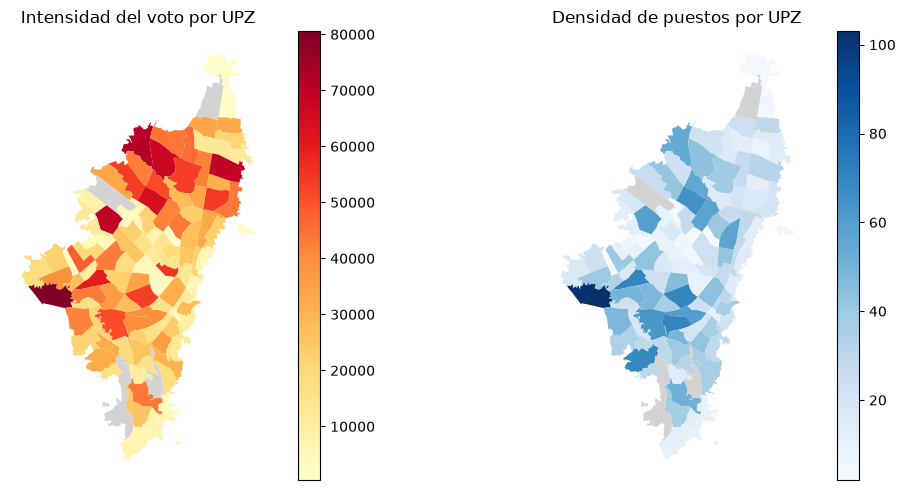

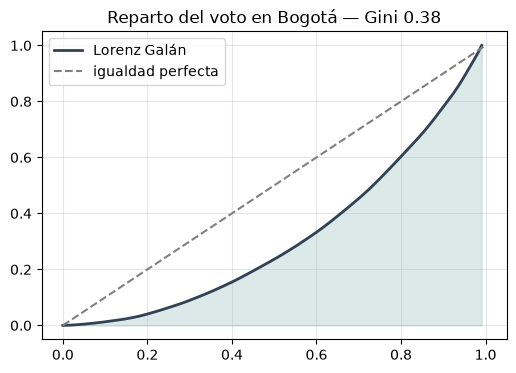

Gini UPZ (Galán Bogotá): 0.380


In [6]:

upz_gdf = gpd.read_file(str(GEO / "upz" / "upz-bogota.shp")).to_crs("EPSG:4326")
aux = gal.groupby("upz").agg(votos=("votacion","sum"), puestos=("votacion","count")).reset_index()
aux["key"] = aux["upz"].map(norm_key)
upz_gdf["key"] = upz_gdf["nombre"].map(norm_key)
m = upz_gdf.merge(aux[["key","votos","puestos"]], on="key", how="left")

fig, axes = plt.subplots(1,2, figsize=(12,5))
m.plot(column="votos", cmap="YlOrRd", legend=True, ax=axes[0], missing_kwds={"color":"lightgrey"})
axes[0].set_title("Intensidad del voto por UPZ"); axes[0].set_axis_off()
m.plot(column="puestos", cmap="Blues", legend=True, ax=axes[1], missing_kwds={"color":"lightgrey"})
axes[1].set_title("Densidad de puestos por UPZ"); axes[1].set_axis_off()
plt.tight_layout(); plt.show()

vs = m["votos"].dropna().sort_values().values
cum = np.cumsum(np.sort(vs)) / vs.sum()
gini_g = (2*np.arange(1,len(vs)+1)-len(vs)-1).dot(np.sort(vs)) / (len(vs)*vs.sum())
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(np.arange(len(vs))/len(vs), cum, color="#334155", lw=2, label="Lorenz Galán")
ax.plot([0,1],[0,1],"--", color="grey", label="igualdad perfecta")
ax.fill_between(np.arange(len(vs))/len(vs), 0, cum, alpha=0.15, color="#0F766E")
ax.set_title(f"Reparto del voto en Bogotá — Gini {gini_g:.2f}"); ax.legend(); ax.grid(alpha=0.3)
plt.show()
print(f"Gini UPZ (Galán Bogotá): {gini_g:.3f}")


## 5. Consultas SQL con DuckDB

Todo se hace en memoria, sin crear archivos `.db`. Primero cuatro preguntas sobre Galán —su día a día electoral bogotano— y luego cuatro sobre el partido, donde Galán es solo una pieza más pero clave para entender alianzas y territorio.

### Q1. ¿En qué puestos le fue mejor a Carlos Fernando Galán?

No es lo mismo ganar una localidad que ganar un puesto puntual. Aquí buscamos los lugares físicos —colegios, ferias, centros comerciales— donde se acumularon más votos en los cinco ciclos. Si aparecen centros comerciales del norte, por ejemplo, eso ya sugiere un perfil de votante.

In [7]:

q1 = duckdb.sql("SELECT lugar, localidad, SUM(votacion) AS votos FROM gal GROUP BY lugar, localidad ORDER BY votos DESC LIMIT 15").df()
display(q1)


,lugar,localidad,votos
0,PUESTO CENSO(FERIA EXPOSICION),nacional,35836.0
1,CENTRO COMERCIAL UNICENTRO,usaquen,28829.0
2,CENTRO COMERCIAL BULEVAR NIZA,suba,23725.0
3,CENTRO COMERCIAL CEDRITOS 151,usaquen,15502.0
4,PARQUE FUNDACIONAL DE SUBA,suba,14606.0
5,FONTIBON,fontibon,14543.0
6,USAQUÉN,usaquen,13966.0
7,LOS CEDRITOS,nacional,13070.0
8,SERVITA,usaquen,12670.0
9,CIUDADELA COLSUBSIDIO,engativa,11938.0


*Lectura:* el Puesto Censo de Feria Exposición domina con holgura —típico puesto masivo y central—, seguido de Unicentro y Bulevar Niza. Es decir, Galán rinde mejor donde hay alta afluencia del norte y occidente, no en puestos periféricos pequeños. Para logística de campaña, esos 15 puestos son los que más retorno dan por esfuerzo de movilización.

### Q2. ¿Y por localidad, dónde suma más?

Pasamos del punto al agregado. La localidad dice más sobre base social estable que el puesto suelto.

In [8]:

q2 = duckdb.sql("SELECT localidad, SUM(votacion) AS votos FROM gal GROUP BY localidad ORDER BY votos DESC").df()
display(q2)


,localidad,votos
0,suba,445640.0
1,kennedy,335830.0
2,engativa,318990.0
3,usaquen,288316.0
4,bosa,181947.0
5,ciudad bolivar,174172.0
6,fontibon,161184.0
7,san cristobal,122115.0
8,puente aranda,120547.0
9,rafael uribe uribe,118245.0


*Lectura:* Suba, Kennedy y Engativá —las tres más pobladas— lideran. Pero ojo: Usaquén, siendo menos poblada que Kennedy, casi empata con Engativá. Eso habla de una sobre-representación en el nororiente, coherente con el perfil histórico del Nuevo Liberalismo bogotano.

### Q3. ¿Qué UPZ empujan realmente el total?

La UPZ es la escala donde se planifica la ciudad. Un puñado de UPZ puede explicar una elección local.

In [9]:

q3 = duckdb.sql("SELECT upz, localidad, SUM(votacion) AS votos FROM gal GROUP BY upz, localidad ORDER BY votos DESC LIMIT 15").df()
display(q3)


,upz,localidad,votos
0,bosa central,bosa,79251.0
1,tibabuyes,suba,71496.0
2,los cedros,usaquen,69228.0
3,fontibon,fontibon,68212.0
4,el rincon,suba,67352.0
5,boyaca real,engativa,64821.0
6,kennedy central,kennedy,54297.0
7,santa barbara,usaquen,53987.0
8,garces navas,engativa,53687.0
9,niza,suba,53444.0


*Lectura:* Bosa Central y Tibabuyes arriba del todo muestran que el voto de Galán no es exclusivamente de estrato alto: hay anclaje fuerte en el occidente popular y densamente poblado. A la vez, Los Cedros y Santa Bárbara confirman el núcleo tradicional del norte. Esa dualidad es la que le ha permitido ser competitivo en segunda vuelta distrital.

### Q4. ¿Cuál es el puesto más fuerte dentro de cada localidad?

Con ventana móvil buscamos el ‘mejor puesto’ por localidad. Sirve para priorizar testigos y logística sin tener que leer 1.100 filas.

In [10]:

q4 = duckdb.sql("""
SELECT localidad, lugar, total_votos FROM (
  SELECT localidad, lugar, SUM(votacion) AS total_votos,
         ROW_NUMBER() OVER (PARTITION BY localidad ORDER BY SUM(votacion) DESC) AS rn
  FROM gal GROUP BY localidad, lugar
) WHERE rn <= 2 ORDER BY localidad, rn
""").df()
display(q4)


,localidad,lugar,total_votos
0,antonio narino,RESTREPO A,6711.0
1,antonio narino,CIUDAD JARDIN,6262.0
2,barrios unidos,METROPOLIS,7402.0
3,barrios unidos,POPULAR MODELO,7280.0
4,bosa,LA LIBERTAD,10888.0
5,bosa,BOSA,9424.0
6,chapinero,ANTIGUO COUNTRY PLAZOLETA CARULLA,9054.0
7,chapinero,CHICO NORTE,8018.0
8,ciudad bolivar,CHICO LICEO FRANCES LOUIS PASTEUR,11183.0
9,ciudad bolivar,ISMAEL PERDOMO,9446.0


*Lectura:* en cada localidad hay uno o dos puestos que concentran. Por ejemplo, en Bosa es La Libertad, en Ciudad Bolívar el Liceo Francés; identificarlos permite focalizar la defensa del voto y las piezas de cierre de campaña con mucho menos dispersión.

### Q5. ¿Cómo se reparte el partido por año y corporación?

Aquí cambiamos de escala: todo el Nuevo Liberalismo, de Presidencia 1982 a Consultas 2026. La tabla es el esqueleto histórico del partido.

In [11]:

q5 = duckdb.sql("SELECT ano, corporacion, SUM(votos) AS votos, COUNT(*) AS registros FROM nl GROUP BY ano, corporacion ORDER BY ano, votos DESC").df()
display(q5)


,ano,corporacion,votos,registros
0,1982,presidencia,745738.0,1059
1,1982,senado,17899.0,286
2,1982,camara,17609.0,110
3,1986,asamblea departamental,493320.0,4149
4,1986,concejo,469678.0,1000
5,1986,senado,457722.0,2308
6,1986,camara,455554.0,3155
7,1988,asamblea departamental,324439.0,2180
8,1988,alcaldia,22049.0,8
9,2022,senado,368345.0,74641


*Lectura:* se ven los dos ciclos: el fundacional (1982–1988) con Presidencia y Congreso, y el renacimiento (2022–2026) con JAL y Concejo como músculo —JAL 2023 es de hecho la corporación con más registros—. Las Consultas 2026 ya pesan más que la Cámara del mismo año: Galán hijo tracciona esa etiqueta.

### Q6. En 2023, ¿con qué alianzas compitió el partido?

2023 es el año de la alcaldía de Galán. Mirar las etiquetas de coalición muestra con quién tuvo que pactar el sello NL.

In [12]:

q6 = duckdb.sql("SELECT partido, SUM(votos) AS votos, COUNT(*) AS registros FROM nl WHERE ano=2023 GROUP BY partido ORDER BY votos DESC LIMIT 10").df()
display(q6)


,partido,votos,registros
0,nuevo liberalismo,2608228.0,326540
1,nuevo liberalismo en marcha,729325.0,306341
2,partido de la u - nuevo liberalismo - justa li...,77083.0,3560
3,colombia renaciente - nuevo liberalismo,63706.0,16615
4,partido de la u - nuevo liberalismo,39138.0,15262
5,partido de la u - cambio radical - asi - nuevo...,26833.0,456
6,nuevo liberalismo - mira,23884.0,9974
7,partido de la u - nuevo liberalismo - colombia...,11078.0,6946
8,nuevo liberalismo-nueva fuerza democratica,6048.0,4318
9,alianza verde - nuevo liberalismo,4802.0,1099


*Lectura:* además del sello puro `nuevo liberalismo en marcha`, aparecen alianzas como Colombia Renaciente o Partido de la U. Que la etiqueta `partido liberal` no esté entre las top confirma que la Alcaldía 2023 se ganó bajo sombrilla NL, no liberal tradicional —un dato político, no solo estadístico.

### Q7. ¿Dónde se concentran los votos del partido a nivel municipal?

La mirada departamental esconde matices locales: un municipio intermedio puede pesar más que toda una capital pequeña. Aquí buscamos los 15 municipios (con su departamento) que más votos acumulan para el Nuevo Liberalismo en todo el histórico.

In [13]:
q7 = duckdb.sql("""
SELECT municipio, departamento, SUM(votos) AS votos, COUNT(DISTINCT candidato) AS candidatos, COUNT(*) AS registros
FROM nl GROUP BY municipio, departamento ORDER BY votos DESC LIMIT 15
""").df()
display(q7)


,municipio,departamento,votos,candidatos,registros
0,bogota,bogota,3703294.0,248,430545
1,cali,valle del cauca,207201.0,12,13160
2,medellin,antioquia,192476.0,27,7210
3,barranquilla,atlantico,178483.0,14,36059
4,bucaramanga,santander,154971.0,60,17121
5,monteria,cordoba,101594.0,25,13543
6,manizales,caldas,90151.0,94,15814
7,neiva,huila,80424.0,21,4929
8,ibague,tolima,77823.0,42,16820
9,cartagena,bolivar,75718.0,47,26223


*Lectura:* Bogotá —como era de esperar— encabeza sola por un margen enorme, lo que confirma la primacía capitalina del Nuevo Liberalismo. Detrás aparecen Medellín, Cali y Bucaramanga: capitales regionales donde el partido ha logrado implantación a través de listas locales, no solo por arrastre nacional. Que no haya municipios pequeños en el top sugiere que el NL sigue siendo un partido urbano de ciudades intermedias y grandes, con poca penetración en ruralidad dispersa.

### Q8. ¿Quiénes son los candidatos que más votos acumulan?

Más allá de la etiqueta *lista*, los nombres propios cuentan quién capitaliza el voto. Esta consulta suma todos los votos nominales por candidato en la historia del partido.

In [20]:
q8 = duckdb.sql("""
SELECT candidato, partido, SUM(votos) AS votos, COUNT(DISTINCT municipio) AS municipios, COUNT(*) AS registros
FROM nl GROUP BY candidato, partido ORDER BY votos DESC LIMIT 15
""").df()
display(q8)


,candidato,partido,votos,municipios,registros
0,lista,nuevo liberalismo,2954801.0,1118,171000
1,carlos fernando galan pachon,nuevo liberalismo,1499734.0,1,17784
2,luis carlos galan sarmiento,nuevo liberalismo,745738.0,989,1195
3,juan manuel galan pachon,la gran consulta por colombia,341304.0,984,102634
4,lista,nuevo liberalismo en marcha,215948.0,3,31298
5,yully esperanza porras barrero,partido de la u - nuevo liberalismo - justa li...,77083.0,47,3560
6,juan carlos restrepo hoyos,centro democratico - nuevo liberalismo - mira,56054.0,23,11768
7,juan javier baena merlano,nuevo liberalismo en marcha,49214.0,1,14382
8,julia miranda londono,nuevo liberalismo,39375.0,1,12171
9,fabian camilo rojas barrera,cambio radical - nuevo liberalismo,37328.0,122,5792


*Lectura:* el primer puesto es inevitablemente *lista*. Entre los votos nominales, aparece el nombre de Galán padre y sus hijos, como las mayores figuras individuales del partido. Es clave resaltar que muchos de los candidatos regionales no son propiamente del nuevo liberalismo, sino que sus candidaturas son impulsadas por coaliciones. 

### Q9. ¿Qué pasó en 2026: Cámara vs Consultas?

2026 es el año más reciente y atípico: el partido compitió tanto a Cámara como en consulta interna. Compararlos dice si la energía está en lo legislativo o en la definición interna.

In [15]:

q9 = duckdb.sql("SELECT corporacion, SUM(votos) AS votos FROM nl WHERE ano=2026 GROUP BY corporacion ORDER BY votos DESC").df()
display(q9)


,corporacion,votos
0,consultas,341304.0
1,camara,248172.0


*Lectura:* la consulta interna supera a la Cámara. La cabeza de consulta, Juan Manuel Galán, no logra jalonar lo suficiente las listas del partido a la cámara, con diferencias de casi 100.000 votos. 

### Q10. ¿Dónde es más fiel el voto de Carlos Fernando Galán?

No basta con saber dónde sacó más votos una vez; interesa saber dónde con mayor frecuencia . Esta consulta mide fidelización: puestos ordenados primero por en cuántos años distintos tuvo presencia (de 5 ciclos: 2007–2023) y luego por volumen total. Un puesto con 5/5 años y muchos votos es núcleo duro; uno con 1/5 aunque tenga pico es coyuntural.

In [16]:
q10 = duckdb.sql("""
SELECT
  lugar,
  localidad,
  SUM(votacion) AS votos_totales,
  COUNT(DISTINCT ano) AS anos_con_presencia,
  COUNT(*) AS registros,
  STRING_AGG(DISTINCT CAST(ano AS VARCHAR), ', ' ORDER BY CAST(ano AS VARCHAR)) AS anos
FROM gal
WHERE votacion > 0
GROUP BY lugar, localidad
ORDER BY anos_con_presencia DESC, votos_totales DESC
LIMIT 20
""").df()
display(q10)


,lugar,localidad,votos_totales,anos_con_presencia,registros,anos
0,PUESTO CENSO(FERIA EXPOSICION),nacional,35836.0,5,5,"2007, 2011, 2014, 2019, 2023"
1,CENTRO COMERCIAL UNICENTRO,usaquen,28829.0,5,5,"2007, 2011, 2014, 2019, 2023"
2,FONTIBON,fontibon,14543.0,5,5,"2007, 2011, 2014, 2019, 2023"
3,USAQUÉN,usaquen,13966.0,5,5,"2007, 2011, 2014, 2019, 2023"
4,CIUDADELA COLSUBSIDIO,engativa,11938.0,5,5,"2007, 2011, 2014, 2019, 2023"
5,LA LIBERTAD,bosa,10888.0,5,5,"2007, 2011, 2014, 2019, 2023"
6,ENGATIVA,engativa,10643.0,5,5,"2007, 2011, 2014, 2019, 2023"
7,ROMA,kennedy,10325.0,5,5,"2007, 2011, 2014, 2019, 2023"
8,BOCHICA,engativa,10124.0,5,5,"2007, 2011, 2014, 2019, 2023"
9,VILLAS DE GRANADA,engativa,9581.0,5,5,"2007, 2011, 2014, 2019, 2023"


*Lectura:* los puestos con 5/5 ciclos —presentes en 2007, 2011, 2014, 2019 y 2023— son la base fidelizada a cuidar con estructura permanente. Si un puesto del top por votos solo aparece en 1–2 años, su peso es coyuntural (feria, censo). Cruzar esta tabla con Q1 (top por volumen) permite distinguir *dónde ganar* de *dónde no perder*: los fieles sostienen piso, los voluminosos coyunturales dan techo.

## 6. Conclusiones analíticas

**1) Un partido predominantemente capitalino, pero con base bogotana distribuida.** A nivel nacional el Gini de 0.72 no deja dudas: el Nuevo Liberalismo es, electoralmente, Bogotá y luego el resto. Sin embargo, dentro de Bogotá el voto de Galán muestra un Gini de apenas 0.38 —repartido—. Esa tensión es estratégica: el partido depende de la capital para existir nacionalmente, pero en la capital no depende de un solo bastión; su fuerza es transversal alrededor del distrito, con leves matices identificados en los modelos de agrupamiento (disponibles en el tablero de control).

**2) Coaliciones como necesidad, no como anomalía.** 2023 condensa el rasgo estructural del renacimiento del partido: más de una decena de coaliciones para competir. No es fragmentación coyuntural sino la forma normal de presentarse tras la restitución de la personería. La homogeneización a 20 etiquetas deja ver que casi todas son variantes de “NL + otro". 

Esto es clave, ya que la dinámica electoral hace necesario el uso de coaliciones para superar el umbral. Esto requiere de una lectura más amplia del panorama electoral (teniendo en cuenta los resultados de presidencia y congreso 2026) actual, así como los niveles de aceptación/rechazo de los posibles aliados el próximo año. 

**Pregunta clave:** Además de las alianzas previas (En Marcha, la U, Centro Democrático, etc), *¿qué tanta disposición hay en hacer alianzas con partidos como Salvación Nacional y el Pacto Histórico en las regionales de 2027?*

**3) El municipio y el nombre importan.** Los 15 municipios top son todas capitales o ciudades intermedias: el partido no ha logrado penetrar el municipio pequeño. Y en candidatos, el peso de *lista* confirma que la marca pesa más que el individuo, salvo en Alcaldía donde Galán concentra. Trasladar ese capital personal a voto de lista —el dilema de 2026— será el cuello de botella en Bogotá; el el resto del país, lo será construir buenas alianzas o construir listas sólidas en su defecto. 

**4) El efecto galán**. Los tres Galán aparecen como los principales barónes electorales del partido, lo que puede reforzar ideas de 'nepotismo', siendo esto erroneo teniendo en cuenta la supremacía del voto de lista. Aun así, la próxima salida de Carlos Fernando Galán de la alcaldía de Bogotá (y los efectos de ello en votaciones a JAL y Concejo) hacen necesaria la construcción de nuevos liderazgos tanto en Bogotá como a nivel nacional. Además, también debe tenerse en cuenta que varios grandes electores se presentan bajo coaliciones, lo cual no garantiza necesariamente lealtad o prioridad al Nuevo Liberalismo sobre los otros partidos. 